<a href="https://colab.research.google.com/github/Huyphung111/TH_DeepLearning/blob/main/TienXuLyDuLieu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Sử dụng thư viện Pandas để đọc tập dữ liệu Titanic từ file CSV vào DataFrame df Sau đó hiển thị 5 dòng đầu tiên để quan sát cấu trúc dữ liệu và dùng info() để kiểm tra số lượng cột, kiểu dữ liệu và số giá trị không rỗng của từng cột

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/titanic_disaster.csv')
print(df.head())
print(df.info())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

2. Kiểm tra dữ liệu thiếu dùng isnull().sum() để đếm số lượng giá trị bị thiếu trong từng cột
tiếp theo, biểu đồ heatmap được vẽ để trực quan hóa vị trí các ô dữ liệu bị thiếu, giúp dễ nhận biết cột nào đang có nhiều giá trị khuyết

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


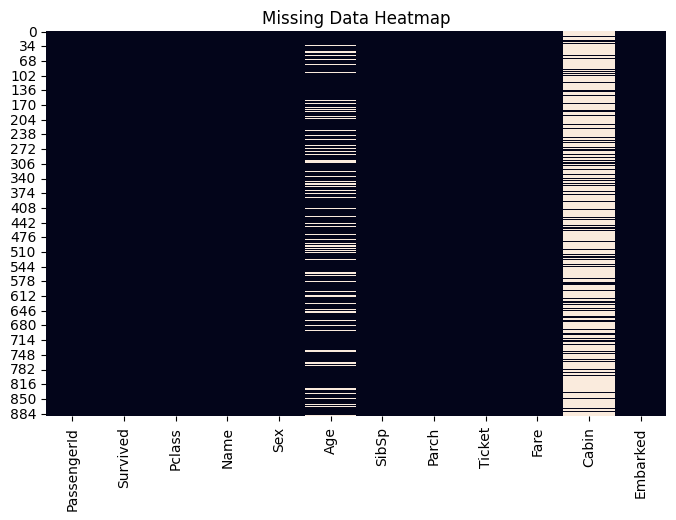

In [3]:
print(df.isnull().sum())

plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()


3. Xử lý dữ liệu thiếu, dữ liệu thiếu trong cột Age được điền bằng giá trị trung bình của cột vì đây là dữ liệu số
Cột Embarked là dữ liệu phân loại nên được điền bằng giá trị xuất hiện nhiều nhất riêng cột Cabin có quá nhiều giá trị thiếu nên được loại bỏ khỏi tập dữ liệu
Sau khi xử lý, chương trình kiểm tra lại để xác nhận dữ liệu thiếu đã được làm sạch

In [4]:
df['Age'].fillna(df['Age'].mean(), inplace=True)


df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.drop(columns=['Cabin'], inplace=True)

print(df.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_4961/461541707.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_4961/461541707.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

4. Xử lý ngoại lai, boxplot của cột Fare được sử dụng để quan sát các giá trị ngoại lai
tiếp đó, phương pháp IQR được áp dụng để xác định ngưỡng dưới và ngưỡng trên của dữ liệu hợp lệ
những dòng có giá trị Fare nằm ngoài khoảng này được xem là ngoại lai và bị loại bỏ khỏi tập dữ liệu

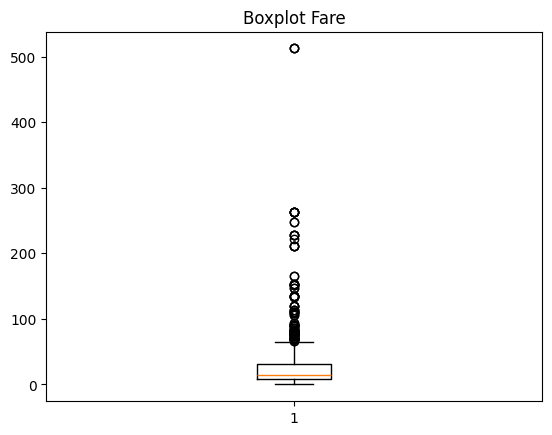

In [5]:
plt.boxplot(df['Fare'])
plt.title("Boxplot Fare")
plt.show()

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]


5. Loại bỏ dữ liệu không hợp lệ, sau khi xử lý thiếu dữ liệu và ngoại lai, chương trình tiếp tục dùng dropna() để loại bỏ các dòng vẫn còn chứa giá trị rỗng, lệnh reset_index() được dùng để đánh lại chỉ số dòng cho dữ liệu sau khi đã xóa bớt các bản ghi, giúp bảng dữ liệu gọn và liên tục hơn

In [10]:
df.dropna(inplace=True)
# reset index
df.reset_index(drop=True, inplace=True)


6. Cân bằng dữ liệu, chương trình đếm số lượng mẫu của từng lớp trong cột Survived để xem dữ liệu có bị mất cân bằng hay không, biểu đồ cột được vẽ để so sánh số lượng giữa hai lớp trước khi cân bằng, phương pháp oversampling được áp dụng: nhóm dữ liệu có ít mẫu hơn được lấy mẫu lặp lại cho đến khi số lượng bằng với nhóm lớn hơn. Cuối cùng, biểu đồ được vẽ lại để cho thấy dữ liệu sau cân bằng đã có số mẫu giữa các lớp tương đối bằng nhau

Survived
0    512
1    263
Name: count, dtype: int64


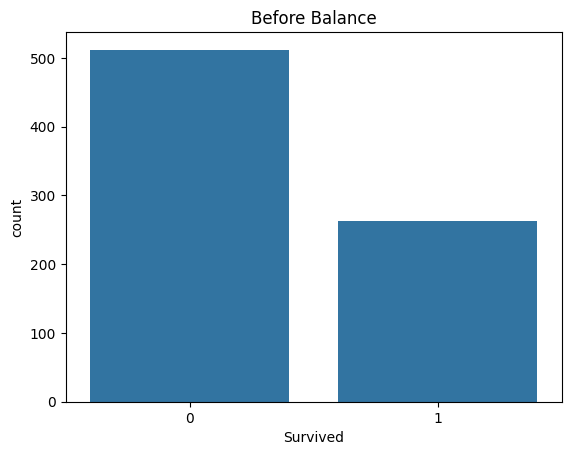

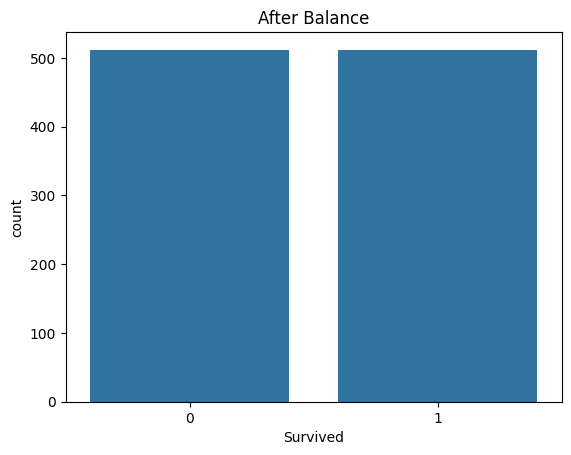

In [11]:
print(df['Survived'].value_counts())

sns.countplot(x='Survived', data=df)
plt.title("Before Balance")
plt.show()

from sklearn.utils import resample

df_major = df[df['Survived']==0]
df_minor = df[df['Survived']==1]

df_minor_upsampled = resample(df_minor,
                             replace=True,
                             n_samples=len(df_major),
                             random_state=42)

df = pd.concat([df_major, df_minor_upsampled])

sns.countplot(x='Survived', data=df)
plt.title("After Balance")
plt.show()


7. Trực quan hóa dữ liệu, chương trình vẽ biểu đồ phân phối cho cột Age và Fare, các biểu đồ này giúp quan sát mức độ phân bố của dữ liệu, xem dữ liệu tập trung nhiều ở khoảng nào và hỗ trợ đánh giá kết quả sau làm sạch

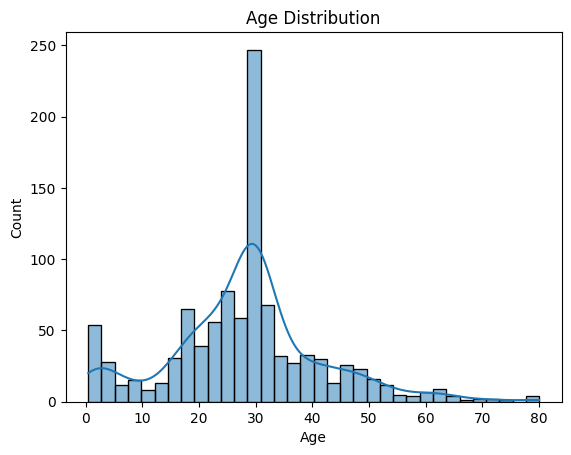

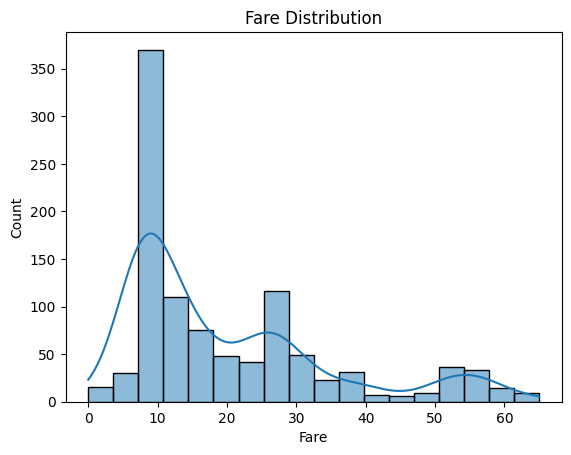

In [12]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(df['Fare'], kde=True)
plt.title("Fare Distribution")
plt.show()


8. Sau toàn bộ quá trình tiền xử lý, dữ liệu cuối cùng được lưu lại thành file cleaned_data.csv

In [13]:
df.to_csv('/content/cleaned_data.csv', index=False)
print("Saved file cleaned_data.csv")

Saved file cleaned_data.csv
